# 04 · The set prediction loss: Hungarian matching

> **Paper:** §3.1, Equations (1) and (2) · **Code:** [`models/matcher.py`](../models/matcher.py), [`SetCriterion`](../models/detr.py#L83)

This is the idea that makes DETR work. The architecture is ordinary; **the loss is the invention.**

**The problem.** The model outputs 100 predictions in a fixed order. The image contains 5 objects in *no* order. How do you compute a loss between an ordered list and an unordered set?

Get this wrong and the model can't learn at all. Get it right and NMS becomes unnecessary.

In [1]:
%matplotlib inline
import torch, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from detr_utils import *   # noqa: F403
from util.box_ops import generalized_box_iou, box_cxcywh_to_xyxy as cxcywh2xyxy

torch.manual_seed(0)
print("ready")

ready


## 1. Why the obvious approaches fail

**Idea A — fix an order** (e.g. sort ground truth left-to-right, compare position by position).
Now prediction #3 is punished for being correct-but-in-the-wrong-slot. The model wastes capacity learning an arbitrary sorting convention, and one extra object at the left edge shifts every target.

**Idea B — match each prediction to its nearest ground-truth box.**
Nothing stops *ten* predictions from all choosing the same cat. They all get rewarded, so the model happily emits ten copies — and now you need NMS again. This is exactly the duplicate problem.

**DETR's answer — a bipartite matching.** Find the *one-to-one* assignment of predictions to ground truths with the lowest total cost. One-to-one is the key: once a prediction claims the cat, no other prediction can, so duplicates are actively penalized.

> *"Our loss produces an optimal bipartite matching between predicted and ground truth objects."* — §3.1

Finding the cheapest one-to-one assignment is a classic problem, solved exactly by the **Hungarian algorithm** in O(n³) — `scipy.optimize.linear_sum_assignment`.

## 2. A toy example you can check by hand

3 predictions, 2 ground-truth objects. Boxes are `(cx, cy, w, h)`, normalized.

In [2]:
# ground truth: a cat on the left, a remote on the right
gt_boxes  = torch.tensor([[0.25, 0.50, 0.30, 0.40],     # object 0
                          [0.75, 0.40, 0.20, 0.20]])    # object 1
gt_labels = torch.tensor([17, 75])                       # 17=cat, 75=remote

# predictions: #0 near the cat, #1 also near the cat (a duplicate!), #2 near the remote
pred_boxes = torch.tensor([[0.27, 0.52, 0.28, 0.38],
                           [0.30, 0.48, 0.34, 0.44],
                           [0.72, 0.42, 0.22, 0.19]])

# class probabilities: pretend the model is fairly confident
pred_probs = torch.full((3, 92), 0.001)
pred_probs[0, 17] = 0.90;  pred_probs[1, 17] = 0.70;  pred_probs[2, 75] = 0.85
pred_probs = pred_probs / pred_probs.sum(-1, keepdim=True)

print("3 predictions vs 2 ground-truth objects")
print("note predictions 0 and 1 are BOTH sitting on the cat")

3 predictions vs 2 ground-truth objects
note predictions 0 and 1 are BOTH sitting on the cat


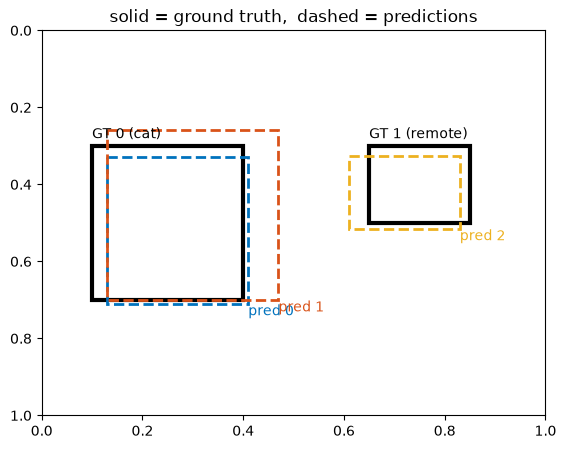

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for i, b in enumerate(cxcywh2xyxy(gt_boxes)):
    ax.add_patch(plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                 fill=False, color="black", lw=3))
    ax.text(b[0], b[1]-0.02, f"GT {i} ({COCO_CLASSES[gt_labels[i]]})", fontsize=10)
for i, b in enumerate(cxcywh2xyxy(pred_boxes)):
    c = COLORS[i]
    ax.add_patch(plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                 fill=False, color=c, lw=2, ls="--"))
    ax.text(b[2], b[3]+0.03, f"pred {i}", color=c, fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.set_title("solid = ground truth,  dashed = predictions")
plt.show()

### The cost matrix

For every (prediction, ground-truth) pair, DETR computes three costs and adds them with the paper's default weights (§4, `--set_cost_*`): **class 1, L1 5, GIoU 2**.

| Term | Formula | Code |
|---|---|---|
| class | `-p̂(correct class)` | `cost_class = -out_prob[:, tgt_ids]` |
| L1 | `‖b_pred − b_gt‖₁` | `torch.cdist(out_bbox, tgt_bbox, p=1)` |
| GIoU | `−GIoU(b_pred, b_gt)` | `-generalized_box_iou(...)` |

Note the class term uses the **probability**, not log-probability. The paper explains: *"we use probabilities... This makes the class prediction term commensurable to the box loss"* (§3.1).

In [4]:
COST_CLASS, COST_BBOX, COST_GIOU = 1.0, 5.0, 2.0

cost_class = -pred_probs[:, gt_labels]                                   # (3, 2)
cost_bbox  = torch.cdist(pred_boxes, gt_boxes, p=1)                      # (3, 2)
cost_giou  = -generalized_box_iou(cxcywh2xyxy(pred_boxes), cxcywh2xyxy(gt_boxes))  # (3, 2)
C = COST_CLASS*cost_class + COST_BBOX*cost_bbox + COST_GIOU*cost_giou    # (3, 2)

np.set_printoptions(precision=3, suppress=True)
for name, m in [("class", cost_class), ("L1", cost_bbox), ("GIoU", cost_giou), ("TOTAL", C)]:
    print(f"{name:>6} cost (rows=preds, cols=GT):\n{m.numpy()}\n")

 class cost (rows=preds, cols=GT):
[[-0.908 -0.001]
 [-0.885 -0.001]
 [-0.001 -0.903]]

    L1 cost (rows=preds, cols=GT):
[[0.08 0.86]
 [0.15 0.91]
 [0.84 0.08]]

  GIoU cost (rows=preds, cols=GT):
[[-0.785  0.504]
 [-0.661  0.402]
 [ 0.446 -0.601]]

 TOTAL cost (rows=preds, cols=GT):
[[-2.078  5.307]
 [-1.457  5.352]
 [ 5.091 -1.705]]



In [5]:
row, col = linear_sum_assignment(C.numpy())
print("Hungarian assignment:")
for r, c_ in zip(row, col):
    print(f"   prediction {r}  ->  ground truth {c_} ({COCO_CLASSES[gt_labels[c_]]})   cost {C[r, c_]:.3f}")
unmatched = sorted(set(range(len(pred_boxes))) - set(row.tolist()))
print(f"   prediction {unmatched}  ->  no object (∅)")
print(f"\ntotal cost: {C[row, col].sum():.3f}")

# brute force check -- with only 3x2 we can enumerate every one-to-one assignment
import itertools
best = min(((sum(C[p[i], i] for i in range(2)), p)
            for p in itertools.permutations(range(3), 2)), key=lambda t: t[0])
print(f"brute-force minimum: {best[0]:.3f} using preds {best[1]}  -> matches: {abs(best[0]-C[row,col].sum())<1e-5}")

Hungarian assignment:
   prediction 0  ->  ground truth 0 (cat)   cost -2.078
   prediction 2  ->  ground truth 1 (remote)   cost -1.705
   prediction [1]  ->  no object (∅)

total cost: -3.784
brute-force minimum: -3.784 using preds (0, 2)  -> matches: True


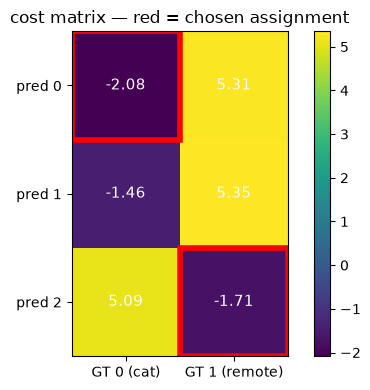

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4))
im_ = ax.imshow(C.numpy(), cmap="viridis")
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center", color="w", fontsize=11)
for r, c_ in zip(row, col):
    ax.add_patch(plt.Rectangle((c_-.5, r-.5), 1, 1, fill=False, edgecolor="red", lw=4))
ax.set_xticks([0, 1], ["GT 0 (cat)", "GT 1 (remote)"])
ax.set_yticks(range(3), [f"pred {i}" for i in range(3)])
ax.set_title("cost matrix — red = chosen assignment")
plt.colorbar(im_); plt.tight_layout(); plt.show()

**Prediction 1 lost.** It was a perfectly reasonable cat box, but prediction 0 was slightly better, and the assignment is one-to-one — so prediction 1 is assigned `∅` and gets *pushed toward "no object"* by the loss.

That single mechanic is what replaces NMS. Duplicates aren't filtered after the fact; they're trained away.

## 3. Why *two* box losses? L1 alone has a scale bug

The paper: *"the most commonly-used ℓ1 loss will have different scales for small and large boxes even if their relative errors are similar"* (§3.1). Watch it happen.

In [7]:
# two errors that are IDENTICAL in relative terms: each box is off by 10% of its own width
small_gt   = torch.tensor([[0.20, 0.20, 0.10, 0.10]])
small_pred = torch.tensor([[0.21, 0.20, 0.10, 0.10]])    # off by 0.01 = 10% of width
large_gt   = torch.tensor([[0.50, 0.50, 0.60, 0.60]])
large_pred = torch.tensor([[0.56, 0.50, 0.60, 0.60]])    # off by 0.06 = 10% of width

for name, p, g in [("small box", small_pred, small_gt), ("large box", large_pred, large_gt)]:
    l1 = torch.cdist(p, g, p=1).item()
    giou = generalized_box_iou(cxcywh2xyxy(p), cxcywh2xyxy(g)).item()
    print(f"{name}:  L1 = {l1:.4f}   GIoU = {giou:.4f}   (1-GIoU = {1-giou:.4f})")

print("\nL1 punishes the large box 6x harder for the SAME relative error.")
print("GIoU is scale-invariant, so it rates both errors almost identically.")

small box:  L1 = 0.0100   GIoU = 0.8182   (1-GIoU = 0.1818)
large box:  L1 = 0.0600   GIoU = 0.8182   (1-GIoU = 0.1818)

L1 punishes the large box 6x harder for the SAME relative error.
GIoU is scale-invariant, so it rates both errors almost identically.


The paper's **Table 4** confirms both are needed: L1 alone gives 35.8 AP, GIoU alone 39.9, **both together 40.6**.

## 4. The real `HungarianMatcher`, on real model output

Everything above is exactly what [`models/matcher.py`](../models/matcher.py) does — batched.

In [8]:
device = get_device()
model = load_pretrained_detr(device=device)
im = load_image("cats")

with torch.no_grad():
    outputs = model(default_transform(im).unsqueeze(0).to(device))
outputs = {k: v.cpu() for k, v in outputs.items()}

# pretend ground truth: 2 cats + 2 remotes (roughly where they are in the photo)
targets = [{
    "labels": torch.tensor([17, 17, 75, 75]),
    "boxes": torch.tensor([[0.26, 0.54, 0.47, 0.87],
                           [0.77, 0.41, 0.46, 0.72],
                           [0.17, 0.20, 0.21, 0.10],
                           [0.55, 0.27, 0.06, 0.24]]),
}]

from models.matcher import HungarianMatcher
matcher = HungarianMatcher(cost_class=1, cost_bbox=5, cost_giou=2)
indices = matcher(outputs, targets)
pred_i, tgt_i = indices[0]

print("out of 100 predictions, these 4 were matched:\n")
probs = outputs["pred_logits"][0].softmax(-1)
for p, t in zip(pred_i.tolist(), tgt_i.tolist()):
    cls = probs[p, :-1].argmax().item()
    print(f"   query {p:3d} -> GT {t} ({COCO_CLASSES[targets[0]['labels'][t]]:<7})"
          f"  model says '{COCO_CLASSES[cls]}' p={probs[p, cls]:.3f}")
print(f"\nthe other {100-len(pred_i)} queries are all assigned ∅ (no object)")

/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


out of 100 predictions, these 4 were matched:

   query  37 -> GT 2 (remote )  model says 'remote' p=0.998
   query  57 -> GT 3 (remote )  model says 'remote' p=0.996
   query  61 -> GT 0 (cat    )  model says 'cat' p=0.999
   query  98 -> GT 1 (cat    )  model says 'cat' p=0.999

the other 96 queries are all assigned ∅ (no object)


## 5. `SetCriterion`: from matching to a number

Once matched, the loss (Eq. 2) is ordinary supervised learning:

- **`loss_ce`** — cross-entropy on classes, over *all* 100 queries (matched ones get their GT class, the rest get `∅`)
- **`loss_bbox`** — L1, on matched pairs only
- **`loss_giou`** — 1 − GIoU, on matched pairs only

In [9]:
from models.detr import SetCriterion
criterion = SetCriterion(
    num_classes=91, matcher=matcher,
    weight_dict={"loss_ce": 1, "loss_bbox": 5, "loss_giou": 2},
    eos_coef=0.1, losses=["labels", "boxes", "cardinality"],
)
losses = criterion(outputs, targets)
for k, v in losses.items():
    print(f"   {k:<18} {float(v):.4f}")

total = sum(losses[k] * w for k, w in criterion.weight_dict.items())
print(f"\n   weighted total     {float(total):.4f}")

   loss_ce            0.0429
   class_error        0.0000
   loss_bbox          0.0079
   loss_giou          0.0516
   cardinality_error  1.0000

   weighted total     0.1858


### `eos_coef` — the class-imbalance fix

95 of 100 queries are `∅`. Left alone, cross-entropy would be dominated by "predict no-object", and the model would learn to detect nothing. DETR down-weights the `∅` class by **10×**:

```python
empty_weight = torch.ones(num_classes + 1)
empty_weight[-1] = self.eos_coef        # 0.1
```

In [10]:
print("empty_weight:", criterion.empty_weight.shape)
print("  weight for the 91 real classes:", criterion.empty_weight[:-1].unique().tolist())
print("  weight for the ∅ class        :", criterion.empty_weight[-1].item())
print()
print("paper §3.1: 'we down-weight the log-probability term when c_i = ∅ by a factor 10")
print("             to account for class imbalance'")

empty_weight: torch.Size([92])
  weight for the 91 real classes: [1.0]
  weight for the ∅ class        : 0.10000000149011612

paper §3.1: 'we down-weight the log-probability term when c_i = ∅ by a factor 10
             to account for class imbalance'


### `cardinality_error` is not a loss

It's decorated `@torch.no_grad()` and never backpropagates ([`models/detr.py:129`](../models/detr.py#L129)). It logs `|predicted object count − true count|` so you can watch the model learn *how many* things are present.

## 6. The matching is recomputed every single step

A crucial and easy-to-miss point: the assignment is **not** fixed. It's recomputed at every forward pass, for every image, and it changes as the model trains. Query 45 might own the left cat this step and nothing at all the next.

This is what makes the loss **permutation-invariant**: the model is never asked to output objects in a particular order — only to produce the right *set*.

In [11]:
# perturb the predictions slightly and watch the assignment move
torch.manual_seed(3)
noisy = {k: v.clone() for k, v in outputs.items()}
noisy["pred_boxes"] += torch.randn_like(noisy["pred_boxes"]) * 0.05

before = matcher(outputs, targets)[0][0].tolist()
after  = matcher(noisy,  targets)[0][0].tolist()
print("matched query ids before noise:", sorted(before))
print("matched query ids after  noise:", sorted(after))
print("changed:", sorted(before) != sorted(after))

matched query ids before noise: [37, 57, 61, 98]
matched query ids after  noise: [8, 35, 65, 98]
changed: True


## What's next

`05` opens the black box: attention maps showing what the encoder and decoder actually look at. `06` puts this loss to work and trains a model from scratch.

## Exercises

**Exercise 1.** Move prediction 1 closer to the cat than prediction 0. Does the assignment flip?

<details><summary>Solution</summary>

```python
pb = pred_boxes.clone()
pb[1] = torch.tensor([0.25, 0.50, 0.30, 0.40])          # exactly on GT 0
C2 = (COST_CLASS * -pred_probs[:, gt_labels]
      + COST_BBOX * torch.cdist(pb, gt_boxes, p=1)
      + COST_GIOU * -generalized_box_iou(cxcywh2xyxy(pb), cxcywh2xyxy(gt_boxes)))
r2, c2 = linear_sum_assignment(C2.numpy())
print("assignment:", list(zip(r2.tolist(), c2.tolist())))
print("total cost:", C2[r2, c2].sum().item(), "(was", C[row, col].sum().item(), ")")
```

Prediction 1 now wins GT 0 and **prediction 0 becomes ∅**. The cost drops, because the matcher always takes the globally cheapest one-to-one assignment.

The lesson: which query "owns" an object is not fixed — it's decided fresh at every training step by whichever prediction currently fits best.
</details>

---

**Exercise 2.** Set `COST_GIOU = 0`, then `COST_BBOX = 0`. Does the matching change?

<details><summary>Solution</summary>

```python
for cc, cb, cg in [(1, 5, 2), (1, 5, 0), (1, 0, 2), (1, 0, 0)]:
    Cx = cc*cost_class + cb*cost_bbox + cg*cost_giou
    r, c_ = linear_sum_assignment(Cx.numpy())
    print(f"class={cc} bbox={cb} giou={cg} -> {list(zip(r.tolist(), c_.tolist()))}")
```

In this easy toy example the assignment is stable — the boxes are far enough apart that any single term picks the same pairing. Matching only becomes sensitive to the weights when candidates are genuinely close, which is the common case in real images.

Note the last row (`bbox=0, giou=0`): matching on class alone is ambiguous, since two predictions share the class "cat".
</details>

---

**Exercise 3.** What happens when there are more ground-truth objects than predictions?

<details><summary>Solution</summary>

```python
gt4 = torch.rand(4, 4).clamp(0.1, 0.4) + torch.tensor([0.2, 0.2, 0.0, 0.0])
lab4 = torch.tensor([17, 75, 17, 75])
C3 = (torch.cdist(pred_boxes, gt4, p=1) * 5
      - generalized_box_iou(cxcywh2xyxy(pred_boxes), cxcywh2xyxy(gt4)) * 2)
r3, c3 = linear_sum_assignment(C3.numpy())
print("3 predictions, 4 targets ->", len(r3), "matches")
```

You get `min(num_queries, num_targets) = 3` matches; one ground-truth object goes **undetected and unsupervised**. That's why N must comfortably exceed the object count — the paper picks N=100 for COCO where the max is 63. With N too small, DETR simply cannot represent all the objects.
</details>

---

**Exercise 4.** Set `eos_coef=1.0` and compare `loss_ce`. Which way does it move, and why?

<details><summary>Solution</summary>

```python
for eos in [0.1, 1.0]:
    crit = SetCriterion(91, matcher, {"loss_ce": 1, "loss_bbox": 5, "loss_giou": 2},
                        eos_coef=eos, losses=["labels"])
    print(f"eos_coef={eos}: loss_ce = {float(crit(outputs, targets)['loss_ce']):.4f}")
```

`loss_ce` goes **up** with `eos_coef=1.0`. The 96 unmatched queries now count 10× more toward the loss, and cross-entropy is an average over all 100 queries.

More importantly it changes what the model *learns*: with `eos_coef=1.0` the overwhelming ∅ majority dominates the gradient and the model drifts toward predicting nothing at all. Down-weighting ∅ by 10× is what keeps the rare "real object" signal audible — the same class-imbalance problem Focal Loss addresses in RetinaNet.
</details>